In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [2]:
pd.options.display.max_rows =20
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_parquet(r"D:\Kaggle datasets\data. india\daily-power-generation.parquet")

In [4]:
df['date'] = pd.to_datetime(df['date'],format='mixed')
for col in ['region', 'state_name', 'sector', 'station_type']:
    df[col] = df[col].astype('category')

In [5]:
df.info(verbose=True,show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2583818 entries, 0 to 2583817
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  2583818 non-null  int64         
 1   date                2583818 non-null  datetime64[us]
 2   region              2583818 non-null  category      
 3   state_name          2583818 non-null  category      
 4   state_code          2571173 non-null  float64       
 5   sector              2571173 non-null  category      
 6   station_type        2571173 non-null  category      
 7   power_station       2583818 non-null  str           
 8   power_station_unit  2583818 non-null  str           
 9   monitored_capacity  2568328 non-null  float64       
 10  todays_gen_prgm     2583815 non-null  float64       
 11  todays_gen_act      2583815 non-null  float64       
dtypes: category(4), datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 219

In [6]:
df.columns

Index(['id', 'date', 'region', 'state_name', 'state_code', 'sector', 'station_type', 'power_station', 'power_station_unit', 'monitored_capacity', 'todays_gen_prgm', 'todays_gen_act'], dtype='str')

In [7]:
df.describe()

,id,date,state_code,monitored_capacity,todays_gen_prgm,todays_gen_act
count,2.583818e+06,2583818,2.571173e+06,2.568328e+06,2.583815e+06,2.583815e+06
mean,1.291908e+06,2021-06-11 11:49:23.657967,2.020276e+01,2.955328e+02,3.965803e+00,3.844455e+00
min,0.000000e+00,2017-01-09 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.459542e+05,2019-06-24 00:00:00,9.000000e+00,1.100000e+02,4.200000e-01,0.000000e+00
50%,1.291908e+06,2021-07-05 00:00:00,2.200000e+01,2.100000e+02,2.840000e+00,2.060000e+00
75%,1.937863e+06,2023-05-08 00:00:00,2.700000e+01,5.000000e+02,5.520000e+00,5.530000e+00
max,2.583817e+06,2025-12-04 00:00:00,3.700000e+01,2.920000e+03,4.651000e+01,1.500000e+02
std,7.458842e+05,NaN,9.747332e+00,2.475515e+02,4.218252e+00,4.721735e+00


In [8]:
df.head()

,id,date,region,state_name,state_code,sector,station_type,power_station,power_station_unit,monitored_capacity,todays_gen_prgm,todays_gen_act
0,0,2017-01-09,Northern,Delhi,7.0,State,Thermal,Rajghat Tps,Unit 1,67.5,0.00,0.00
1,1,2017-01-09,Northern,Delhi,7.0,State,Thermal,Rajghat Tps,Unit 2,67.5,0.00,0.00
2,2,2017-01-09,Northern,Delhi,7.0,State,Ther (Gt),I.P.Ccpp,Single Unit,270.0,1.80,0.87
3,3,2017-01-09,Northern,Delhi,7.0,State,Ther (Gt),Pragati Ccgt-Iii,Single Unit,1500.0,6.00,10.89
4,4,2017-01-09,Northern,Delhi,7.0,State,Ther (Gt),Pragati Ccpp,Single Unit,330.4,5.49,6.53


In [9]:
# there was certain bad data from compilation, so cleaning it.
df = df[~df['power_station'].str.contains('Type|Total|TOTAL|Sum', case=False, na=False)]

### Data Distribution

Analytical Framework: Quantifying the absolute contribution of individual generation technologies to map the foundational energy mix.


Empirical Findings: Thermal power dominantly anchors the baseline at 83% of aggregate generation. Hydro infrastructure serves as the primary alternative at 10.8%, while Nuclear units maintain a rigid baseline share of 3.32%.


In [10]:
sector_pie = df.groupby('station_type')['todays_gen_act'].sum().reset_index()
sector_pie_fig=px.pie(data_frame=sector_pie,names='station_type',values='todays_gen_act',title='total electricty generation by station type',)
sector_pie_fig.show()

### Grid Reliability & Fulfillment Metric

Analytical Framework: Evaluating cross-regional operational execution by benchmarking aggregate actual generation against programmed targets and assessing daily variance.


Empirical Findings: The Western and Eastern regions operate closest to programmed baselines, with the Eastern grid maintaining a slight surplus (101.26%) to offset wider system stress. The Southern region exhibits the most significant supply strain, running a persistent deficit with a 91.6% fulfillment rate.

In [11]:
df['variance'] = df['todays_gen_act'] - df['todays_gen_prgm']

In [12]:
regional_perf = df.groupby('region').agg(total_programmed=('todays_gen_prgm', 'sum'),total_actual=('todays_gen_act', 'sum'), avg_daily_variance=('variance', 'mean')).reset_index()

regional_perf['fulfillment_rate'] = (regional_perf['total_actual'] / regional_perf['total_programmed']) * 100


In [13]:
regional_perf

,region,total_programmed,total_actual,avg_daily_variance,fulfillment_rate
0,Bhutan Imp.,51304.80,46750.73,-0.447047,91.123501
1,Eastern,1654601.35,1675490.86,0.051247,101.262510
2,North Eastern,152521.38,142067.96,-0.142779,93.146259
3,Northern,2544073.46,2431845.16,-0.169049,95.588638
4,Southern,2099430.01,1923144.50,-0.281007,91.603173
5,Western,3696216.33,3669435.98,-0.033513,99.275466


In [14]:
# regional Performance plotting
labels = regional_perf['fulfillment_rate'].round(2).astype(str) + '%'
regional_perf_fig = px.bar(data_frame=regional_perf,x='region',y=['fulfillment_rate'],text=labels,)
regional_perf_fig.show()

### Asset Efficiency: Plant Capacity Utilization Rate
Analytical Framework: Calculating the Plant Load Factor (PLF) across asset classes by converting monitored capacity into maximum daily potential and measuring real-world output ratios.

Empirical Findings: Nuclear assets register the highest utilization efficiency, averaging a 69.65% operating rate. Thermal plants follow at 58.15%, whereas demand-driven or intermittent resources like Hydro (37.26%) and Gas-fired units (21.64%) reflect expectedly lower capacity deployment.

In [15]:
active_plants = df[df['monitored_capacity']>0].copy()
active_plants['max_daily_gen_mu'] = (active_plants['monitored_capacity']* 24)/1000
active_plants['utilization_rate_pct'] = (active_plants['todays_gen_act']/active_plants['max_daily_gen_mu']) * 100
station_summary = active_plants.groupby('station_type')['utilization_rate_pct'].mean().sort_values(ascending=False).reset_index()
station_summary

,station_type,utilization_rate_pct
0,Nuclear,69.654593
1,Thermal,58.152481
2,Hydro,37.264683
3,Ther (Gt),21.643014
4,Ther (Dg),6.875866


In [16]:
#plotting Station summary
labels = station_summary['utilization_rate_pct'].round(2).astype(str)+'%'
station_summary_fig=px.bar(data_frame=station_summary,x='station_type',y='utilization_rate_pct',text=labels)
station_summary_fig.update_layout(xaxis_title='Types of Power Stations',yaxis_title='Utilization rate in %')
station_summary_fig.show()

### Grid Risk Profiling: Chronic Outage Identification

Analytical Framework: Isolating system vulnerabilities and asset failure frequencies by filtering for days where programmed targets were active but actual production dropped to absolute zero.

Empirical Findings: High-volume zero-generation windows expose severe reliability risks in state-sector assets. Suratgarh TPS (8,484 outages) and Raichur TPS (7,166 outages) serve as the primary drivers of localized grid instability.

In [17]:
outage_threshold = 0.5 
outages=df[(df['todays_gen_prgm']>outage_threshold)&(df['todays_gen_act']==0)]

frequent_failures = outages.groupby(['region', 'state_name', 'state_code', 'sector','station_type', 'power_station']).size().sort_values(ascending=False).reset_index(name='outages')


In [18]:
print('power stations with frequent outages :\n',frequent_failures.head(10))

power stations with frequent outages :
      region      state_name  state_code   sector station_type      power_station  outages
0  Northern       Rajasthan         8.0    State      Thermal      Suratgarh Tps     8484
1  Southern       Karnataka        29.0    State      Thermal        Raichur Tps     7166
2  Northern          Punjab         3.0    State      Thermal          Ropar Tps     6093
3   Western         Gujarat        24.0    State      Thermal      Wanakbori Tps     5893
4  Northern          Punjab         3.0    State      Thermal  Gh Tps (Leh.Moh.)     5657
5  Southern  Andhra Pradesh        28.0    State      Thermal    Rayalaseema Tps     4088
6  Southern      Tamil Nadu        33.0    State      Thermal  North Chennai Tps     4082
7  Northern   Uttar Pradesh         9.0  Central      Thermal      Dadri (Nctpp)     3976
8   Eastern     West Bengal        19.0  Central      Thermal          Mejia Tps     3783
9   Western     Chhatisgarh        22.0  Private      Therma

In [19]:
#plotting frequent failures
frequent_failures_fig=px.treemap(data_frame=frequent_failures,path=['station_type','power_station'],values ='outages',height=800,width=800,
                                 title='Power Station Outages')
frequent_failures_fig.show()

### Power Generation Timeline Analysis:

Analytical Framework: Evaluating multi-year temporal trends from 2017 through 2025 to observe structural capacity shifts and seasonal baseline behavior.

Empirical Findings: Long-term trendlines confirm that Thermal generation absorbs the brunt of macroscopic demand spikes. The timeline clearly segregates the highly volatile, weather-dependent cycles of Hydro power from the flat, unvarying baseline output maintained by Nuclear infrastructure.

In [20]:
timeline = df.groupby(['date', 'station_type'])['todays_gen_act'].sum().reset_index()

timeline_pivot = timeline.pivot(index='date', columns='station_type', values='todays_gen_act').reset_index()

timeline_pivot['Total']= timeline_pivot['Hydro'] + timeline_pivot['Nuclear'] +timeline_pivot['Ther (Dg)'] +timeline_pivot['Ther (Gt)'] + timeline_pivot['Thermal']

In [21]:
timeline_pivot.head()

station_type,date,Hydro,Nuclear,Ther (Dg),Ther (Gt),Thermal,Total
0,2017-01-09,497.68,89.18,0.27,115.16,2416.96,3119.25
1,2017-01-11,262.25,109.18,0.27,143.27,2680.09,3195.06
2,2017-01-12,208.90,130.45,0.27,136.01,2554.50,3030.13
3,2017-02-09,495.63,92.28,0.27,110.56,2452.54,3151.28
4,2017-02-11,284.08,109.20,0.27,146.33,2668.72,3208.60


In [22]:
# plotting timeline Pivot
timeline_pivot_fig = px.line(data_frame=timeline_pivot,x='date',y=['Hydro','Nuclear','Ther (Dg)','Ther (Gt)','Thermal'])
timeline_pivot_fig.update_layout(yaxis_title='Million Units',xaxis_title='timeline')
timeline_pivot_fig.show()

In [23]:
#plotting total energy generated
total_fig = px.line(data_frame=timeline_pivot,x='date',y='Total',title='Total Energy generated Timeline')
total_fig.update_layout(yaxis_title='Million Units',xaxis_title='timeline')
total_fig.show()

### State-Level Grid Supply Disparity Analysis

Analytical Framework: Aggregating net planning-to-production deltas at the state level to identify structural supply anomalies and regional over-reliance.

Empirical Findings: Systemic Deficits: Tamil Nadu and Gujarat exhibit the highest absolute shortfalls, where real-world generation regularly drops below targets due to fuel constraints or unplanned downtime.

Systemic Surpluses: Chhattisgarh and West Bengal consistently outpace scheduled programming, acting as vital export anchors that stabilize the national grid.

In [24]:
state_summary = df.groupby('state_name').agg(
    total_prog=('todays_gen_prgm', 'sum'),
    total_act=('todays_gen_act', 'sum')
)
state_summary['net_gap_mu'] = state_summary['total_act'] - state_summary['total_prog']
state_summary['performance_index'] = (state_summary['total_act'] / state_summary['total_prog']) * 100

# Sort to find the top net surplus and net deficit states
underperforming_states = state_summary.sort_values(by='net_gap_mu').head(5)
overperforming_states = state_summary.sort_values(by='net_gap_mu', ascending=False).head(5)

In [25]:
underperforming_states

,total_prog,total_act,net_gap_mu,performance_index
state_name,,,,
Tamil Nadu,689471.47,620228.71,-69242.76,89.957125
Gujarat,728473.41,672658.41,-55815.00,92.338087
Uttar Pradesh,1082675.55,1027952.50,-54723.05,94.945573
Andhra Pradesh,522226.50,470701.27,-51525.23,90.133547
Karnataka,412582.31,378598.15,-33984.16,91.763059


In [26]:
overperforming_states

,total_prog,total_act,net_gap_mu,performance_index
state_name,,,,
Chhatisgarh,961501.03,1001895.73,40394.70,104.201212
West Bengal,597680.45,614611.34,16930.89,102.832766
Madhya Pradesh,971675.38,987857.90,16182.52,101.665425
Odisha,438103.86,444246.26,6142.40,101.402042
Uttarakhand,106980.98,111308.97,4327.99,104.045570


In [27]:
# plotting net gap in planning and production
state_summary_fig= px.bar(data_frame=state_summary,x=state_summary.index,y='net_gap_mu',height=600,)
state_summary_fig.show()

### Regional Generation Profiles: Cross-Tabulation Matrix

Analytical Framework: Generating a row-normalized percentage distribution matrix to isolate independent regional fuel dependencies irrespective of total national volume.

Empirical Findings: The matrix exposes severe geographic dependency imbalances. The Eastern and Western zones are strictly locked into thermal generation (exceeding 90%), whereas the North Eastern grid displays a diversified, lower-carbon portfolio anchored by gas (48.1%) and hydro (31.2%).

In [28]:
# Pivot matrix to see energy mix percentages by region
region_mix = pd.crosstab(index=df['region'],columns=df['station_type'],values=df['todays_gen_act'],aggfunc='sum',normalize='index') * 100

region_mix

station_type,Hydro,Nuclear,Ther (Dg),Ther (Gt),Thermal
region,,,,,
Eastern,8.007499,0.000000,0.085141,0.002319,91.905041
North Eastern,31.241738,0.000000,0.000000,48.105850,20.652412
Northern,22.255531,3.210295,0.000000,2.829074,71.705099
Southern,11.687393,7.864588,0.008356,1.729891,78.709773
Western,3.139406,2.665082,0.000000,3.241039,90.954473


In [29]:
# plotting corelation betn power production corelation betn region
region_mix_fig= px.imshow(region_mix,height=500,width=500,color_continuous_scale='Picnic',text_auto='.1f')
region_mix_fig.show()

### Dynamic Flexibility: Ramping Volatility Analysis

Analytical Framework: Measuring first-order temporal differences per generation unit to calculate the standard deviation of daily output shifts during active operational phases.

Empirical Findings: Nuclear and Thermal units exhibit the highest standard deviation in daily ramps. This proves that baseload assets face intense mechanical stress, swinging output constantly to balance the grid due to a deficit in utility-scale storage alternatives.

In [30]:
df = df.sort_values(by=['power_station_unit', 'date'])

df['daily_ramp'] = df.groupby('power_station_unit')['todays_gen_act'].diff()

active_operating_days = df[(df['todays_gen_prgm']>0.5) & (df['todays_gen_act']!=0.0)]

true_active_volatility = active_operating_days.groupby('station_type')['daily_ramp'].std().sort_values(ascending=False).reset_index()
true_active_volatility

,station_type,daily_ramp
0,Nuclear,7.399393
1,Thermal,6.586381
2,Ther (Gt),5.441843
3,Hydro,5.123128
4,Ther (Dg),4.590038


In [31]:
true_active_volatility_fig =px.bar(data_frame=true_active_volatility,x='station_type',y='daily_ramp',text_auto=True,
                                  title='Active Daily Ramping Volatility by Station Type')
true_active_volatility_fig.update_layout(xaxis_title='Station Type',yaxis_title='Volatility(sd in MU)')
true_active_volatility_fig.show()

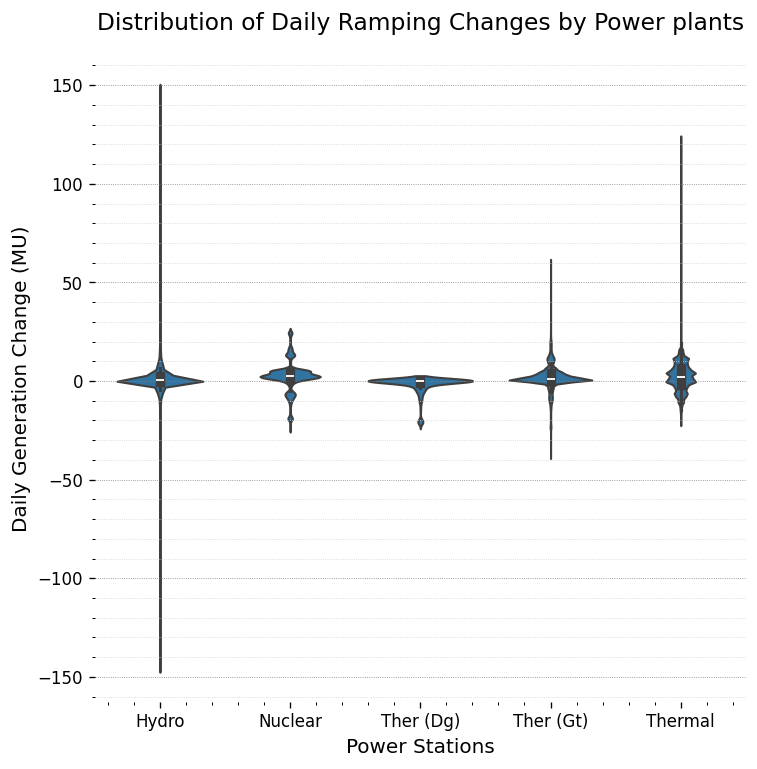

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,7),dpi=120)
sns.violinplot(data=active_operating_days,x='station_type',y='daily_ramp')
sns.despine(right=True,left=True,bottom=True,top=True)
plt.title('Distribution of Daily Ramping Changes by Power plants', fontsize=14, pad=15)
plt.xlabel('Power Stations', fontsize=12)
plt.ylabel('Daily Generation Change (MU)', fontsize=12)
#plt.ylim(-100,50)
plt.minorticks_on()
plt.grid(which='major', linestyle=':', linewidth='0.5', color='grey',axis='y')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgrey',axis='y')

plt.show()

### Pareto Allocation of Grid Deficits
Analytical Framework: Modeling a cumulative percentage distribution of negative variance days across facilities to isolate the primary drivers of total supply shortfalls.

Empirical Findings: The distribution reflects a classic Pareto structure. The top 50% of the entire grid's supply deficit is heavily concentrated within a tiny cluster of high-capacity assets, led directly by massive merchant operations like Mundra UMTPP and North Chennai TPS.

In [33]:
# Isolate deficit days
deficits = df[df['variance'] < 0].copy()
deficits['absolute_deficit'] = deficits['variance'].abs()

# Group by power station and find total lost energy
station_deficits = deficits.groupby('power_station')['absolute_deficit'].sum().sort_values(ascending=False).reset_index()

# Calculate running cumulative percentage
total_grid_deficit = station_deficits['absolute_deficit'].sum()
station_deficits['cumulative_pct'] = (station_deficits['absolute_deficit'].cumsum()/total_grid_deficit) * 100

# Filter for the stations causing the top 50% of all grid shortfalls
chronic_offenders = station_deficits[station_deficits['cumulative_pct'] <= 50].reset_index()

In [34]:
chronic_offenders_fig=px.area(data_frame=chronic_offenders,x='power_station',y='cumulative_pct',hover_data='absolute_deficit',height=500)
chronic_offenders_fig.update_layout(xaxis_title='Power Station',yaxis_title='% of grid shortfall')
chronic_offenders_fig.show()

### Regional Interdependence and Deficit Balancing Analysis

Analytical Framework: Deriving a Pearson correlation matrix from daily regional generation variances to evaluate inter-regional balancing and power transfer capabilities.

Empirical Findings: Low correlation coefficients between most zones indicate independent risk profiles, allowing power to be routed dynamically to cover localized deficits. However, positive correlations between the Southern, Northern, and Western grids point to synchronized risk windows where concurrent demand spikes limit mutual backup capacity.

In [35]:
daily_regional_variance = df.groupby(['date', 'region'])['variance'].sum().unstack()
grid_correlation = daily_regional_variance.corr()
print(grid_correlation)

region         Bhutan Imp.   Eastern  North Eastern  Northern  Southern   Western
region                                                                           
Bhutan Imp.       1.000000 -0.070533       0.056160  0.123859 -0.172453 -0.195453
Eastern          -0.070533  1.000000       0.344095  0.356638  0.398908  0.218699
North Eastern     0.056160  0.344095       1.000000  0.228618  0.047906 -0.194111
Northern          0.123859  0.356638       0.228618  1.000000  0.407069  0.384008
Southern         -0.172453  0.398908       0.047906  0.407069  1.000000  0.411262
Western          -0.195453  0.218699      -0.194111  0.384008  0.411262  1.000000


In [36]:
a = px.imshow(grid_correlation,height=600,width=600)
a.show()